<a href="https://colab.research.google.com/github/DengDuangLang111/494-algo-representations/blob/task3/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/494data/notes-00001.zip', 'r') as z:
    print(z.namelist())

df_new = pd.read_csv('/content/drive/MyDrive/494data/notes-00001.zip', sep='\t', compression='zip')
print(df_new.columns.tolist())
print(df_new['isCollaborativeNote'].value_counts())

['notes-00001.tsv']
['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId', 'classification', 'believable', 'harmful', 'validationDifficulty', 'misleadingOther', 'misleadingFactualError', 'misleadingManipulatedMedia', 'misleadingOutdatedInformation', 'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact', 'misleadingSatire', 'notMisleadingOther', 'notMisleadingFactuallyCorrect', 'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire', 'notMisleadingPersonalOpinion', 'trustworthySources', 'summary', 'isMediaNote', 'isCollaborativeNote']
isCollaborativeNote
1    5312
Name: count, dtype: int64


In [ ]:
df_new_00000 = pd.read_csv('/content/drive/MyDrive/494data/notes-00000 (1).zip', sep='\t', compression='zip', low_memory=False)
print(df_new_00000['isCollaborativeNote'].value_counts())

isCollaborativeNote
0    2432704
Name: count, dtype: int64


In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/494data/noteStatusHistory-00000 (1).zip', 'r') as z:
    print(z.namelist())

status = pd.read_csv('/content/drive/MyDrive/494data/noteStatusHistory-00000 (1).zip', sep='\t', compression='zip', low_memory=False)
print(status.columns.tolist())
print(status.shape)
print(status.head(3))

['noteStatusHistory-00000.tsv']
['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus', 'timestampMillisOfCurrentStatus', 'currentStatus', 'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus', 'timestampMillisOfStatusLock', 'lockedStatus', 'timestampMillisOfRetroLock', 'currentCoreStatus', 'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy', 'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange', 'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus', 'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput', 'timestampMillisOfFirstNmrDueToMinStableCrhTime']
(2618198, 23)
                noteId                            noteAuthorParticipantId  \
0  1352796878438424576  B021517F4F8F9F372DCD70BB8F8A21A80C12D7EFDE8B2F...   
1  1353415873227177985  D4C9EDB464DF2D4A6D8F68CA8D1F86226B50EB9D3B0F33...   
2  1354586938863443971  C0AF45F4C4B2240E7AB31456957E5D770FF7AFA13627

In [ ]:
df_all = pd.concat([df_new_00000, df_new], ignore_index=True)
print(f"Total notes: {len(df_all)}")
print(df_all['isCollaborativeNote'].value_counts())

Total notes: 2438016
isCollaborativeNote
0    2432704
1       5312
Name: count, dtype: int64


In [ ]:
status_slim = status[['noteId', 'currentStatus', 'firstNonNMRStatus', 'mostRecentNonNMRStatus', 'timestampMillisOfFirstNonNMRStatus']]

collab = df_all[df_all['isCollaborativeNote'] == 1].copy()
collab_with_status = collab.merge(status_slim, on='noteId', how='left')

print(collab_with_status.shape)
print(collab_with_status['currentStatus'].value_counts())

(5312, 28)
currentStatus
NEEDS_MORE_RATINGS             4080
CURRENTLY_RATED_NOT_HELPFUL      49
CURRENTLY_RATED_HELPFUL          39
Name: count, dtype: int64


In [ ]:
print(f"Status NaN count: {collab_with_status['currentStatus'].isna().sum()}")

no_status = collab_with_status[collab_with_status['currentStatus'].isna()]
no_status['date'] = pd.to_datetime(no_status['createdAtMillis'], unit='ms').dt.date
print(no_status['date'].value_counts().sort_index())

Status NaN count: 1144
date
2026-01-21      2
2026-01-22      1
2026-01-23      4
2026-01-27      1
2026-02-04      3
2026-02-05     12
2026-02-06     25
2026-02-08     17
2026-02-09     75
2026-02-10    100
2026-02-11     56
2026-02-12     36
2026-02-13     67
2026-02-14     83
2026-02-15     77
2026-02-16     69
2026-02-17     74
2026-02-18     70
2026-02-19     84
2026-02-20    104
2026-02-21     62
2026-02-22     98
2026-02-23     24
Name: count, dtype: int64


/tmp/ipython-input-2796/3796000309.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_status['date'] = pd.to_datetime(no_status['createdAtMillis'], unit='ms').dt.date


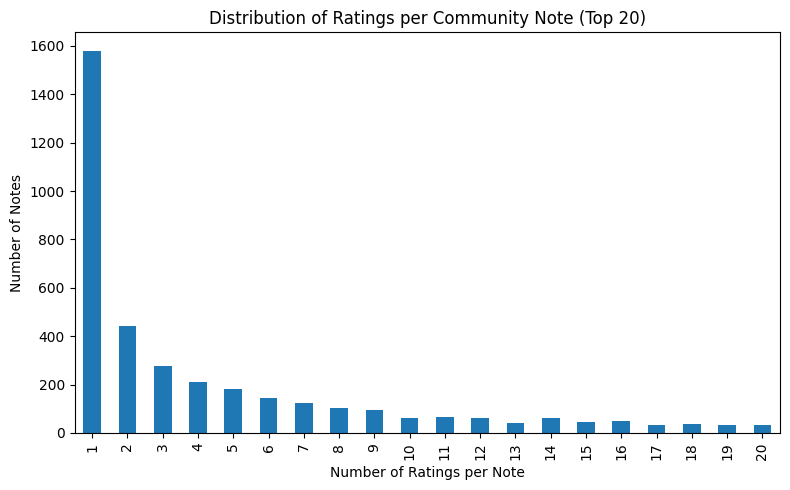

In [115]:
top = rating_distribution.head(20)

plt.figure(figsize=(8,5))

top.plot(kind="bar")

plt.xlabel("Number of Ratings per Note")
plt.ylabel("Number of Notes")
plt.title("Distribution of Ratings per Community Note (Top 20)")

plt.tight_layout()
plt.show()

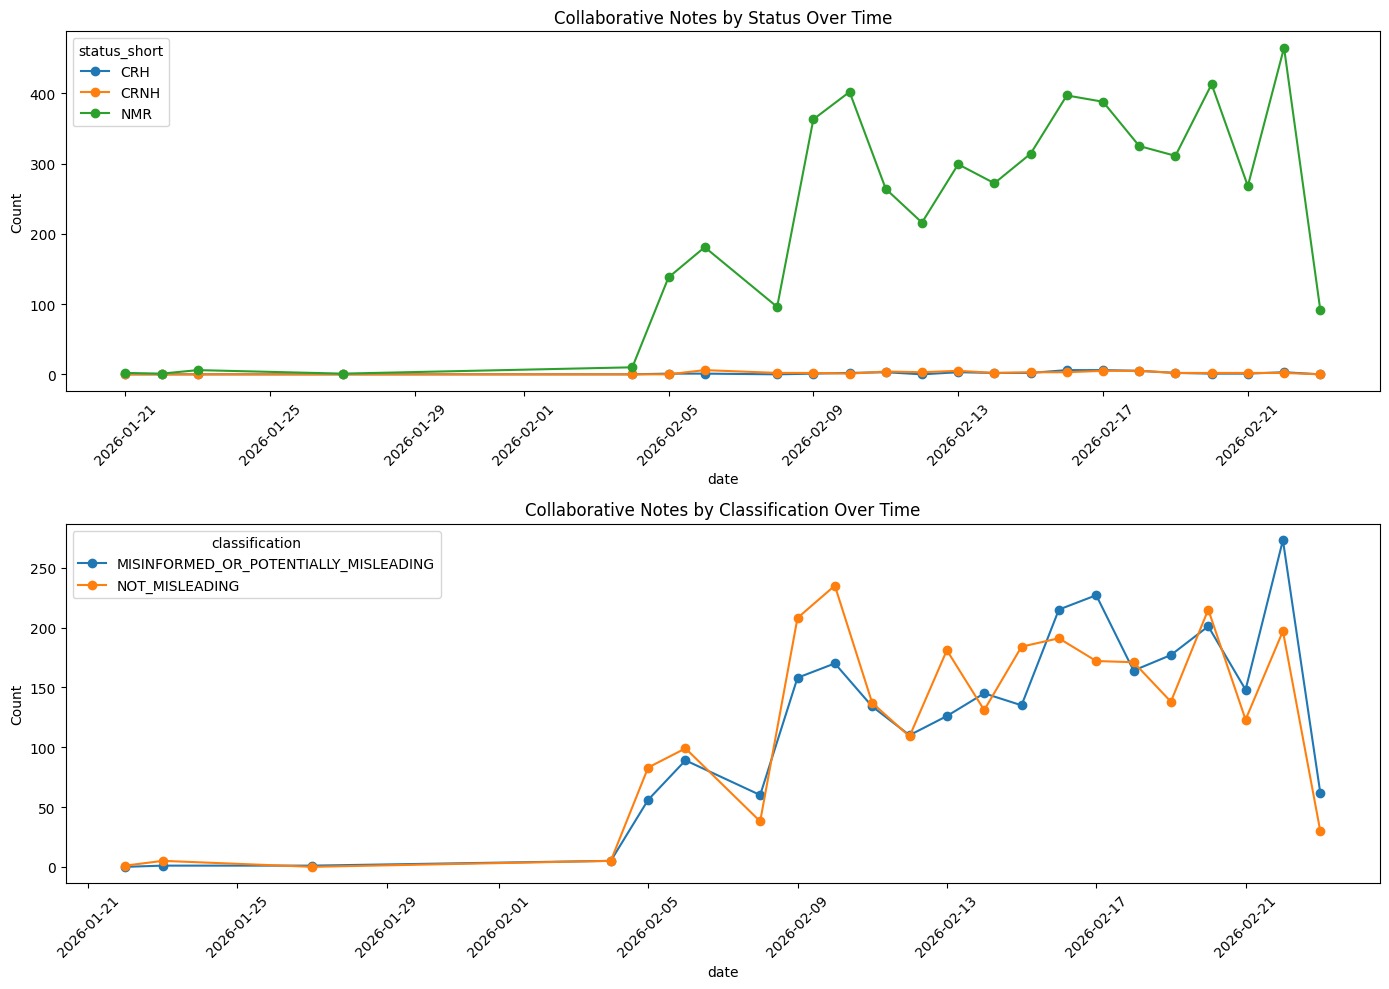

Classification distribution:
classification
MISINFORMED_OR_POTENTIALLY_MISLEADING    2657
NOT_MISLEADING                           2653
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

collab_with_status['date'] = pd.to_datetime(collab_with_status['createdAtMillis'], unit='ms').dt.date

daily = collab_with_status.groupby('date').size()

status_map = {
    'NEEDS_MORE_RATINGS': 'NMR',
    'CURRENTLY_RATED_HELPFUL': 'CRH',
    'CURRENTLY_RATED_NOT_HELPFUL': 'CRNH'
}
collab_with_status['status_short'] = collab_with_status['currentStatus'].map(status_map).fillna('NMR')

daily_by_status = collab_with_status.groupby(['date', 'status_short']).size().unstack(fill_value=0)

daily_by_class = collab_with_status.groupby(['date', 'classification']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))


daily_by_status.plot(ax=ax1, marker='o')
ax1.set_title('Collaborative Notes by Status Over Time')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)


daily_by_class.plot(ax=ax2, marker='o')
ax2.set_title('Collaborative Notes by Classification Over Time')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Classification distribution:")
print(collab_with_status['classification'].value_counts())

In [ ]:
collab_with_status['status_flipped'] = (
    collab_with_status['firstNonNMRStatus'].notna() &
    collab_with_status['mostRecentNonNMRStatus'].notna() &
    (collab_with_status['firstNonNMRStatus'] != collab_with_status['mostRecentNonNMRStatus'])
)

print("Status flips:")
print(collab_with_status['status_flipped'].value_counts())

flipped = collab_with_status[collab_with_status['status_flipped'] == True]
print("\nFlip details (firstNonNMR -> mostRecentNonNMR):")
print(flipped.groupby(['firstNonNMRStatus', 'mostRecentNonNMRStatus']).size())

print(f"\nNotes that ever left NMR: {collab_with_status['firstNonNMRStatus'].notna().sum()}")
print(f"Total notes with status: {collab_with_status['currentStatus'].notna().sum()}")

Status flips:
status_flipped
False    5312
Name: count, dtype: int64

Flip details (firstNonNMR -> mostRecentNonNMR):
Series([], dtype: int64)

Notes that ever left NMR: 128
Total notes with status: 4168


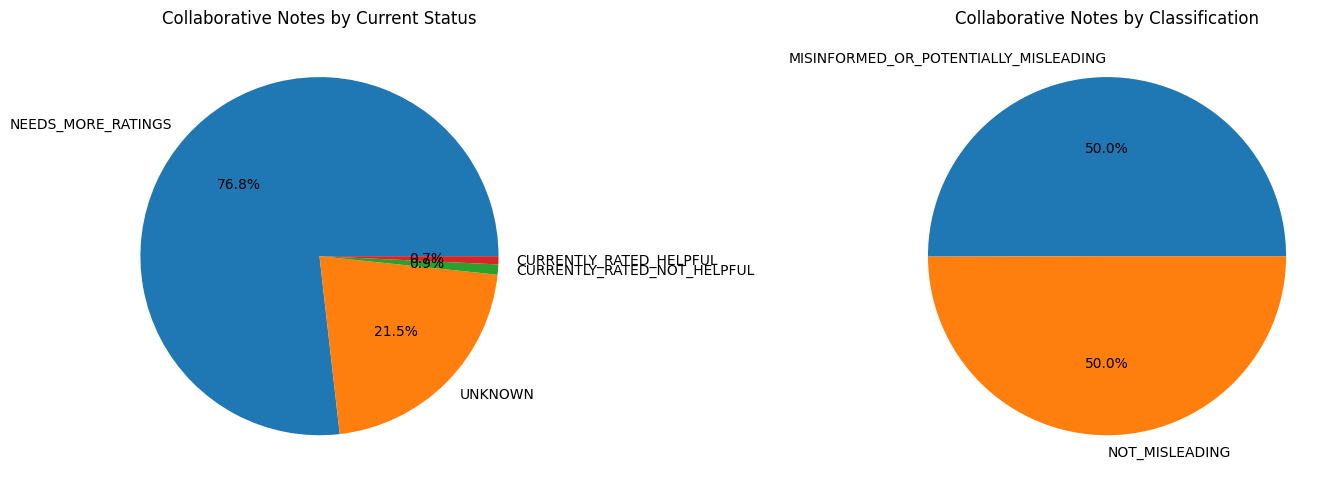

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = collab_with_status['currentStatus'].fillna('UNKNOWN').value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
axes[0].set_title('Collaborative Notes by Current Status')

class_counts = collab_with_status['classification'].value_counts()
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
axes[1].set_title('Collaborative Notes by Classification')

plt.tight_layout()
plt.show()

In [ ]:
cross = pd.crosstab(
    collab_with_status['classification'],
    collab_with_status['currentStatus'].fillna('UNKNOWN'),
    normalize='index'
)
print(cross)

decided = collab_with_status[collab_with_status['currentStatus'].isin(['CURRENTLY_RATED_HELPFUL', 'CURRENTLY_RATED_NOT_HELPFUL'])]
print("\nAmong decided notes:")
print(pd.crosstab(decided['classification'], decided['currentStatus']))

currentStatus                          CURRENTLY_RATED_HELPFUL  \
classification                                                   
MISINFORMED_OR_POTENTIALLY_MISLEADING                 0.014678   
NOT_MISLEADING                                        0.000000   

currentStatus                          CURRENTLY_RATED_NOT_HELPFUL  \
classification                                                       
MISINFORMED_OR_POTENTIALLY_MISLEADING                     0.011291   
NOT_MISLEADING                                            0.007162   

currentStatus                          NEEDS_MORE_RATINGS   UNKNOWN  
classification                                                       
MISINFORMED_OR_POTENTIALLY_MISLEADING            0.885585  0.088446  
NOT_MISLEADING                                   0.650961  0.341877  

Among decided notes:
currentStatus                          CURRENTLY_RATED_HELPFUL  \
classification                                                   
MISINFORMED_OR_POTEN

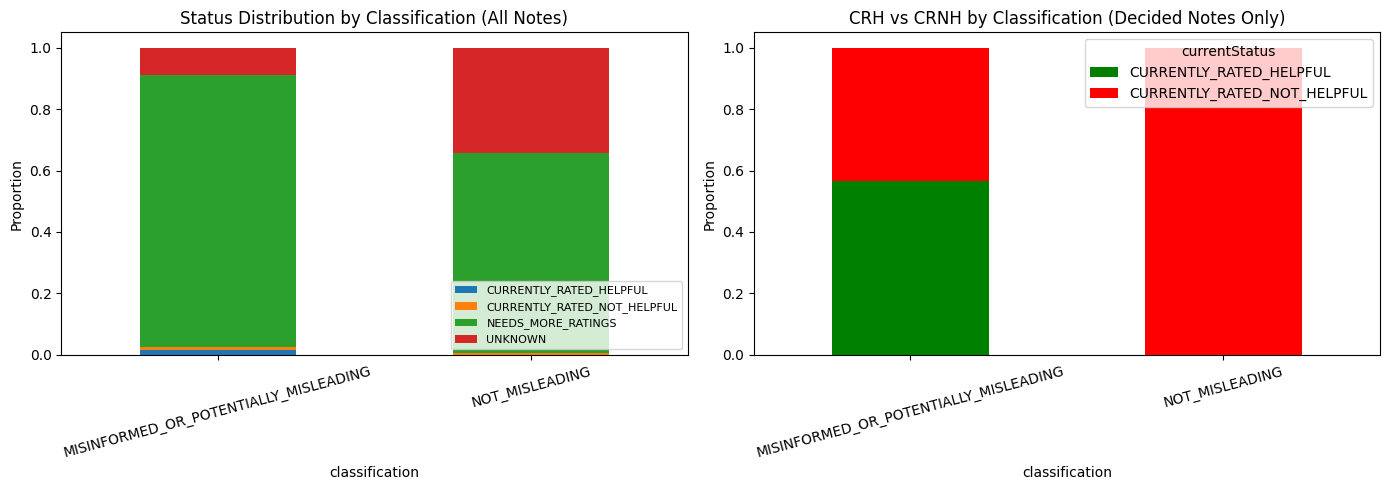

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross_all = pd.crosstab(
    collab_with_status['classification'],
    collab_with_status['currentStatus'].fillna('UNKNOWN'),
    normalize='index'
)
cross_all.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Status Distribution by Classification (All Notes)')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right', fontsize=8)

decided = collab_with_status[collab_with_status['currentStatus'].isin(
    ['CURRENTLY_RATED_HELPFUL', 'CURRENTLY_RATED_NOT_HELPFUL']
)]
cross_decided = pd.crosstab(
    decided['classification'],
    decided['currentStatus'],
    normalize='index'
)
cross_decided.plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'red'])
axes[1].set_title('CRH vs CRNH by Classification (Decided Notes Only)')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
unknown = collab_with_status[collab_with_status['currentStatus'].isna()]

print(f"Unknown count: {len(unknown)}")
print(f"\nDate range:")
print(f"  Earliest: {unknown['date'].min()}")
print(f"  Latest: {unknown['date'].max()}")

unknown_ids = unknown['noteId'].tolist()
status_match = status[status['noteId'].isin(unknown_ids)]
print(f"\nHow many unknown notes appear in status file: {len(status_match)}")

print("\nClassification distribution of unknown notes:")
print(unknown['classification'].value_counts(normalize=True))

print("\nClassification distribution of known notes:")
print(collab_with_status[collab_with_status['currentStatus'].notna()]['classification'].value_counts(normalize=True))

Unknown count: 1144

Date range:
  Earliest: 2026-01-21
  Latest: 2026-02-23

How many unknown notes appear in status file: 0

Classification distribution of unknown notes:
classification
NOT_MISLEADING                           0.794221
MISINFORMED_OR_POTENTIALLY_MISLEADING    0.205779
Name: proportion, dtype: float64

Classification distribution of known notes:
classification
MISINFORMED_OR_POTENTIALLY_MISLEADING    0.581094
NOT_MISLEADING                           0.418906
Name: proportion, dtype: float64


In [ ]:
decided = collab_with_status[collab_with_status['currentStatus'].isin(
    ['CURRENTLY_RATED_HELPFUL', 'CURRENTLY_RATED_NOT_HELPFUL']
)]
print(pd.crosstab(decided['classification'], decided['currentStatus']))

currentStatus                          CURRENTLY_RATED_HELPFUL  \
classification                                                   
MISINFORMED_OR_POTENTIALLY_MISLEADING                       39   
NOT_MISLEADING                                               0   

currentStatus                          CURRENTLY_RATED_NOT_HELPFUL  
classification                                                      
MISINFORMED_OR_POTENTIALLY_MISLEADING                           30  
NOT_MISLEADING                                                  19  


To see how many notes are collaborativenote by ai

In [ ]:
collab = df_all[df_all['isCollaborativeNote'] == 1]
print(f"Collaborative notes: {len(collab)}")
print(f"Proportion: {len(collab)/len(df_all)*100:.2f}%")

Collaborative notes: 5312
Proportion: 0.22%


Plot the ai collaborate note with time

In [ ]:
!pip install transformers torch -q

from transformers import pipeline

topic_classifier = pipeline(
    'text-classification',
    model='cardiffnlp/tweet-topic-latest-multi',
    tokenizer='cardiffnlp/tweet-topic-latest-multi',
    top_k=1
)

sample = collab_with_status['summary'].dropna().head(5).tolist()
for text in sample:
    result = topic_classifier(text[:512])
    print(f"Text: {text[:80]}...")
    print(f"Topic: {result}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/tweet-topic-latest-multi
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Text: Claim that Avicii, Bennington, Cornell, Bourdain worked on child trafficking doc...
Topic: [[{'label': 'news_&_social_concern', 'score': 0.9980862140655518}]]

Text: The video in this post is fabricated; no such Zelensky poster exists in Milan, a...
Topic: [[{'label': 'news_&_social_concern', 'score': 0.9938755631446838}]]

Text: The attack shown occurred in Bordeaux, France on June 19, 2023. The suspect, whi...
Topic: [[{'label': 'news_&_social_concern', 'score': 0.9950976967811584}]]

Text: Sources show ~7 German NGO ships were active in Med Sea in Sep 2023, not 8; Germ...
Topic: [[{'label': 'news_&_social_concern', 'score': 0.9952012300491333}]]

Text: Video shows 2021 flogging at Nigerian madrasa for student misbehavior like drink...
Topic: [[{'label': 'news_&_social_concern', 'score': 0.986786425113678}]]



In [ ]:
text = collab_with_status['summary'].iloc[0]
result = topic_classifier(str(text)[:512], top_k=1)
print(type(result))
print(result)
print(result[0])
print(type(result[0]))

<class 'list'>
[{'label': 'news_&_social_concern', 'score': 0.9980862140655518}]
{'label': 'news_&_social_concern', 'score': 0.9980862140655518}
<class 'dict'>


In [ ]:
def get_topic(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'no_text'
    try:
        result = topic_classifier(str(text)[:512], top_k=1)
        return result[0]['label']
    except Exception as e:
        return 'error'

collab_with_status['topic_pred'] = collab_with_status['summary'].apply(get_topic)

print(collab_with_status['topic_pred'].value_counts())

topic_pred
news_&_social_concern       3645
science_&_technology         702
sports                       251
celebrity_&_pop_culture      179
fitness_&_health             149
film_tv_&_video              100
gaming                        44
diaries_&_daily_life          44
arts_&_culture                33
travel_&_adventure            33
music                         33
business_&_entrepreneurs      31
learning_&_educational        30
food_&_dining                 10
fashion_&_style                9
relationships                  8
other_hobbies                  6
youth_&_student_life           3
family                         2
Name: count, dtype: int64


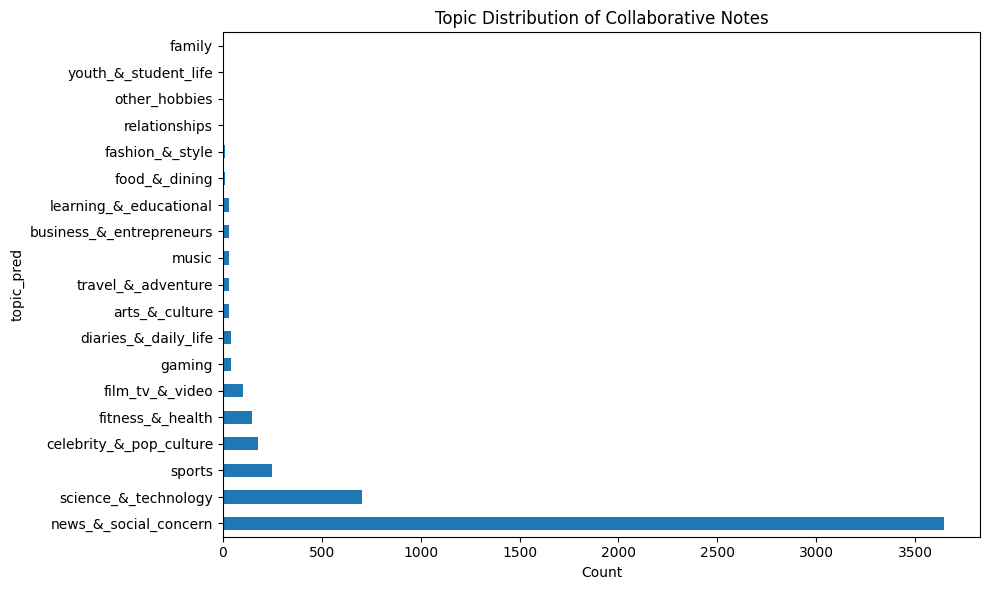

In [ ]:
topic_counts = collab_with_status['topic_pred'].value_counts()
topic_counts.plot(kind='barh', figsize=(10, 6))
plt.title('Topic Distribution of Collaborative Notes')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
ratings_files = [
'/content/drive/MyDrive/494data/ratings-00000.zip',
'/content/drive/MyDrive/494data/ratings-00001.zip',
'/content/drive/MyDrive/494data/ratings-00002 (1).zip',
'/content/drive/MyDrive/494data/ratings-00003 (1).zip',
'/content/drive/MyDrive/494data/ratings-00004.zip',
'/content/drive/MyDrive/494data/ratings-00005.zip',
'/content/drive/MyDrive/494data/ratings-00006.zip'
]

print(pd.read_csv(ratings_files[0], sep='\t', compression='zip', nrows=5).columns)

Index(['noteId', 'raterParticipantId', 'createdAtMillis', 'version', 'agree',
       'disagree', 'helpful', 'notHelpful', 'helpfulnessLevel', 'helpfulOther',
       'helpfulInformative', 'helpfulClear', 'helpfulEmpathetic',
       'helpfulGoodSources', 'helpfulUniqueContext', 'helpfulAddressesClaim',
       'helpfulImportantContext', 'helpfulUnbiasedLanguage', 'notHelpfulOther',
       'notHelpfulIncorrect', 'notHelpfulSourcesMissingOrUnreliable',
       'notHelpfulOpinionSpeculationOrBias', 'notHelpfulMissingKeyPoints',
       'notHelpfulOutdated', 'notHelpfulHardToUnderstand',
       'notHelpfulArgumentativeOrBiased', 'notHelpfulOffTopic',
       'notHelpfulSpamHarassmentOrAbuse', 'notHelpfulIrrelevantSources',
       'notHelpfulOpinionSpeculation', 'notHelpfulNoteNotNeeded',
       'ratedOnTweetId', 'ratingSourceBucketed', 'suggestion'],
      dtype='object')


In [ ]:
from tqdm import tqdm

use_cols = [
    "noteId",
    "createdAtMillis",
    "helpful",
    "notHelpful",
    "version"
]

ratings_list = []

for f in tqdm(ratings_files, desc="Loading ratings"):
    df = pd.read_csv(
        f,
        sep='\t',
        compression='zip',
        usecols=use_cols,
        low_memory=False
    )
    ratings_list.append(df)

ratings_all = pd.concat(ratings_list, ignore_index=True)

print("Total ratings:", len(ratings_all))
print(ratings_all.head())

Loading ratings: 100%|██████████| 7/7 [10:39<00:00, 91.39s/it]


Total ratings: 201214101
                noteId  createdAtMillis  version  helpful  notHelpful
0  1970937352257520007    1758832064413        2        0           0
1  1970937352257520007    1758751360175        2        0           0
2  1970938033802445182    1758987031796        2        0           0
3  1970938033802445182    1758779796587        2        0           0
4  1970938033802445182    1758822235610        2        0           0


In [ ]:
collab_ids = set(collab['noteId'].tolist())
ratings_collab = ratings_all[ratings_all['noteId'].isin(collab_ids)].copy()

print("Ratings on collaborative notes:", len(ratings_collab))
ratings_collab.head()

Ratings on collaborative notes: 41670


,noteId,createdAtMillis,version,helpful,notHelpful
22647517,2014117943958012199,1769128077708,2,0,0
22648808,2014121093532098991,1769117393958,2,0,0
22891693,2014466977717485974,1769128425651,2,0,0
22923789,2014495172550406429,1769180881772,2,0,0
22923797,2014495284156387774,1769180958997,2,0,0


In [ ]:
ratings_collab = ratings_collab.merge(
    collab[['noteId','tweetId','createdAtMillis']],
    on='noteId',
    how='left'
)

In [ ]:
ratings_collab['rating_time'] = pd.to_datetime(
    ratings_collab['createdAtMillis_x'],
    unit='ms'
)

ratings_collab['note_time'] = pd.to_datetime(
    ratings_collab['createdAtMillis_y'],
    unit='ms'
)

In [ ]:
ratings_collab['day'] = (
    ratings_collab['rating_time'] -
    ratings_collab['note_time']
).dt.days

ratings_collab = ratings_collab[ratings_collab['day'] >= 0]

In [ ]:
ratings_collab['helpful_flag'] = (
    ratings_collab['helpful'] == 1
).astype(int)

In [ ]:
daily_stats = (
    ratings_collab
    .groupby(['tweetId','noteId','day'])
    .agg(
        ratings_count=('noteId','count'),
        helpful_count=('helpful_flag','sum')
    )
    .reset_index()
)

daily_stats['helpful_ratio'] = (
    daily_stats['helpful_count'] /
    daily_stats['ratings_count']
)

In [ ]:
daily_stats.head()

,tweetId,noteId,day,ratings_count,helpful_count,helpful_ratio
0,-1,2014117943958012199,1,1,0,0.0
1,-1,2014121093532098991,0,1,0,0.0
2,-1,2014466977717485974,0,1,0,0.0
3,-1,2014495172550406429,0,1,0,0.0
4,-1,2014495284156387774,0,1,0,0.0


In [ ]:
daily_stats = daily_stats.sort_values(['noteId','day'])

daily_stats['ratings_cum'] = (
    daily_stats
    .groupby('noteId')['ratings_count']
    .cumsum()
)

In [ ]:
avg_traj = (
    daily_stats
    .groupby('day')
    .agg({
        'ratings_count':'mean',
        'helpful_ratio':'mean'
    })
    .reset_index()
)

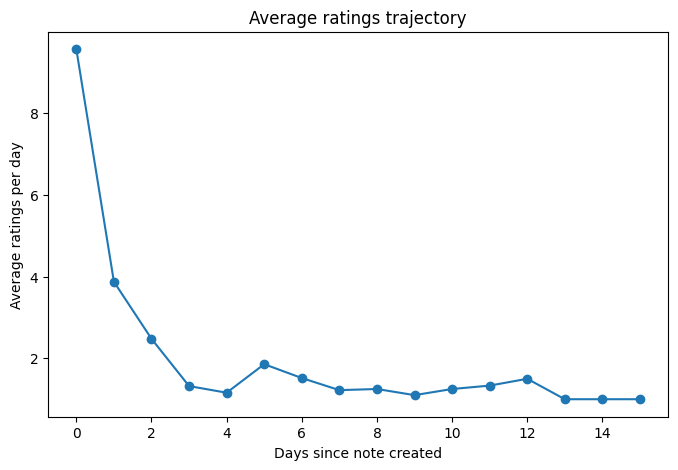

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    avg_traj['day'],
    avg_traj['ratings_count'],
    marker='o'
)

plt.xlabel("Days since note created")
plt.ylabel("Average ratings per day")
plt.title("Average ratings trajectory")

plt.show()

In [ ]:
ratings_collab.columns

Index(['noteId', 'createdAtMillis_x', 'version', 'helpful', 'notHelpful',
       'tweetId', 'createdAtMillis_y', 'rating_time', 'note_time', 'day',
       'helpful_flag'],
      dtype='object')

In [ ]:
ratings_all.columns

Index(['noteId', 'createdAtMillis', 'version', 'helpful', 'notHelpful'], dtype='object')

In [ ]:
print("RATINGS SHAPE:")
print(ratings_all.shape)

print("\nRATINGS COLUMNS:")
print(ratings_all.columns)

print("\nRATINGS TYPES:")
print(ratings_all.dtypes)

print("\nRATINGS SAMPLE:")
ratings_all.head()

RATINGS SHAPE:
(201214101, 5)

RATINGS COLUMNS:
Index(['noteId', 'createdAtMillis', 'version', 'helpful', 'notHelpful'], dtype='object')

RATINGS TYPES:
noteId             int64
createdAtMillis    int64
version            int64
helpful            int64
notHelpful         int64
dtype: object

RATINGS SAMPLE:


,noteId,createdAtMillis,version,helpful,notHelpful
0,1970937352257520007,1758832064413,2,0,0
1,1970937352257520007,1758751360175,2,0,0
2,1970938033802445182,1758987031796,2,0,0
3,1970938033802445182,1758779796587,2,0,0
4,1970938033802445182,1758822235610,2,0,0


In [ ]:
ratings_all['helpful'].value_counts()
ratings_all['notHelpful'].value_counts()

,count
notHelpful,
0,201202142
1,11959


In [ ]:
ratings_collab[['helpful','notHelpful']].sum()

,0
helpful,0
notHelpful,0


In [ ]:
ratings_all[['helpful','notHelpful']].sum()

,0
helpful,22006
notHelpful,11959


In [ ]:
collab_with_status.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdatedInformation',
       'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact',
       'misleadingSatire', 'notMisleadingOther',
       'notMisleadingFactuallyCorrect',
       'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire',
       'notMisleadingPersonalOpinion', 'trustworthySources', 'summary',
       'isMediaNote', 'isCollaborativeNote', 'currentStatus',
       'firstNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfFirstNonNMRStatus'],
      dtype='object')

In [ ]:
print("STATUS SHAPE:")
print(status.shape)

print("\nSTATUS COLUMNS:")
print(status.columns)

print("\nSTATUS TYPES:")
print(status.dtypes)

print("\nSTATUS SAMPLE:")
status.head()

STATUS SHAPE:
(2618198, 23)

STATUS COLUMNS:
Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime'],
      dtype='object')

STATUS TYPES:
noteId                                              int64
noteAuthorParticipantId                            object
createdAtMillis                                     int64
timestampMil

,noteId,noteAuthorParticipantId,createdAtMillis,timestampMillisOfFirstNonNMRStatus,firstNonNMRStatus,timestampMillisOfCurrentStatus,currentStatus,timestampMillisOfLatestNonNMRStatus,mostRecentNonNMRStatus,timestampMillisOfStatusLock,...,currentExpansionStatus,currentGroupStatus,currentDecidedBy,currentModelingGroup,timestampMillisOfMostRecentStatusChange,timestampMillisOfNmrDueToMinStableCrhTime,currentMultiGroupStatus,currentModelingMultiGroup,timestampMinuteOfFinalScoringOutput,timestampMillisOfFirstNmrDueToMinStableCrhTime
0,1352796878438424576,B021517F4F8F9F372DCD70BB8F8A21A80C12D7EFDE8B2F...,1611366884227,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29530368,NaN
1,1353415873227177985,D4C9EDB464DF2D4A6D8F68CA8D1F86226B50EB9D3B0F33...,1611514464087,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29530368,NaN
2,1354586938863443971,C0AF45F4C4B2240E7AB31456957E5D770FF7AFA13627C7...,1611793667892,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),6.0,-1,NaN,NaN,NaN,29530368,NaN
3,1354588003075764229,9C480F7B2E882F19F9FBF75BD13FEA53031875AC42FDF6...,1611793921619,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NaN,NaN,ExpansionPlusModel (v1.1),NaN,-1,NaN,NaN,NaN,29530368,NaN
4,1354588172659920899,931B6CFE7C2FDF3653B0A63DC20DF3C51F8AA3BEB9D613...,1611793962051,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NaN,NaN,ExpansionPlusModel (v1.1),NaN,-1,NaN,NaN,NaN,29530368,NaN


In [ ]:
print("NOTES SHAPE:")
print(df_all.shape)

print("\nNOTES COLUMNS:")
print(df_all.columns)

print("\nNOTES TYPES:")
print(df_all.dtypes)

print("\nNOTES SAMPLE:")
df_all.head()

NOTES SHAPE:
(2438016, 24)

NOTES COLUMNS:
Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdatedInformation',
       'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact',
       'misleadingSatire', 'notMisleadingOther',
       'notMisleadingFactuallyCorrect',
       'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire',
       'notMisleadingPersonalOpinion', 'trustworthySources', 'summary',
       'isMediaNote', 'isCollaborativeNote'],
      dtype='object')

NOTES TYPES:
noteId                                     int64
noteAuthorParticipantId                   object
createdAtMillis                            int64
tweetId                                    int64
classification                            object
believable                               

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,misleadingSatire,notMisleadingOther,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,isCollaborativeNote
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,1,The House failed to pass a border protection l...,0,0
1,1783181538789605871,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978583415,1783171851818021181,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,1,...,0,0,0,0,0,0,1,The United States has 50 States https://da...,0,0
2,1783182562279494134,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978827435,1783154445682979015,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,1,TikTok only mentions “ban” and chooses to igno...,0,0
3,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,0,0,1,This could be considered a threat https://...,0,0
4,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,0,0,1,Forbes has a good rundown of the investigation...,0,0


In [ ]:
collab_with_status['currentStatus'].value_counts()

,count
currentStatus,
NEEDS_MORE_RATINGS,4080
CURRENTLY_RATED_NOT_HELPFUL,49
CURRENTLY_RATED_HELPFUL,39


In [ ]:
resolved = collab_with_status[
    collab_with_status['currentStatus'] != 'NEEDS_MORE_RATINGS'
]

In [ ]:
resolved['currentStatus'].value_counts()

,count
currentStatus,
CURRENTLY_RATED_NOT_HELPFUL,49
CURRENTLY_RATED_HELPFUL,39


In [ ]:
resolved.groupby(['classification','currentStatus']).size().unstack()

currentStatus,CURRENTLY_RATED_HELPFUL,CURRENTLY_RATED_NOT_HELPFUL
classification,,
MISINFORMED_OR_POTENTIALLY_MISLEADING,39.0,30.0
NOT_MISLEADING,NaN,19.0


In [ ]:
cols = [
'misleadingFactualError',
'misleadingManipulatedMedia',
'misleadingOutdatedInformation',
'misleadingMissingImportantContext',
'misleadingUnverifiedClaimAsFact'
]

for c in cols:
    print(c)
    print(resolved.groupby(c)['currentStatus'].value_counts())
    print()

misleadingFactualError
misleadingFactualError  currentStatus              
0                       CURRENTLY_RATED_NOT_HELPFUL    49
                        CURRENTLY_RATED_HELPFUL        39
Name: count, dtype: int64

misleadingManipulatedMedia
misleadingManipulatedMedia  currentStatus              
0                           CURRENTLY_RATED_NOT_HELPFUL    49
                            CURRENTLY_RATED_HELPFUL        39
Name: count, dtype: int64

misleadingOutdatedInformation
misleadingOutdatedInformation  currentStatus              
0                              CURRENTLY_RATED_NOT_HELPFUL    49
                               CURRENTLY_RATED_HELPFUL        39
Name: count, dtype: int64

misleadingMissingImportantContext
misleadingMissingImportantContext  currentStatus              
0                                  CURRENTLY_RATED_NOT_HELPFUL    49
                                   CURRENTLY_RATED_HELPFUL        39
Name: count, dtype: int64

misleadingUnverifiedClaimAsFact
misleadi

In [ ]:
resolved.groupby('validationDifficulty')['currentStatus'].value_counts()

,,count
validationDifficulty,currentStatus,


In [ ]:
collab['noteId'].head(20)


,noteId
2432704,2021411467829051490
2432705,2023532126180876533
2432706,2024855965028553026
2432707,2019853905044086819
2432708,2021044437527249321
2432709,2023932146948469248
2432710,2021043093001412733
2432711,2021042937912594435
2432712,2021282602569654773
2432713,2021046073062560255


In [ ]:
sample_ids = collab['noteId'].sample(10)

ratings_all[ratings_all['noteId'].isin(sample_ids)]

,noteId,createdAtMillis,version,helpful,notHelpful
26866454,2021017565670277240,1770683413814,2,0,0
26885785,2021048401778147839,1770691172155,2,0,0
27398030,2021953979916464360,1770907005422,2,0,0
27561576,2022281355837501643,1771123287257,2,0,0
27561577,2022281355837501643,1771032797529,2,0,0
...,...,...,...,...,...
28316644,2023746094354891138,1771334914341,2,0,0
28316645,2023746094354891138,1771334729556,2,0,0
28316646,2023746094354891138,1771335315480,2,0,0
28316647,2023746094354891138,1771335453859,2,0,0


In [ ]:
collab_ids = set(collab['noteId'])
rating_ids = set(ratings_all['noteId'])

len(collab_ids.intersection(rating_ids))

4187

In [ ]:
print(collab['noteId'].min(), collab['noteId'].max())
print(ratings_all['noteId'].min(), ratings_all['noteId'].max())

2014117943958012199 2025781233029099922
1352796878438424576 2025782235954065794


In [ ]:
collab['noteId'].isin(ratings_all['noteId']).sum()

np.int64(4187)

In [ ]:
ratings_collab = ratings_all.merge(
    collab[['noteId']],
    on='noteId',
    how='inner'
)

In [ ]:
print(ratings_collab.shape)

(41670, 5)


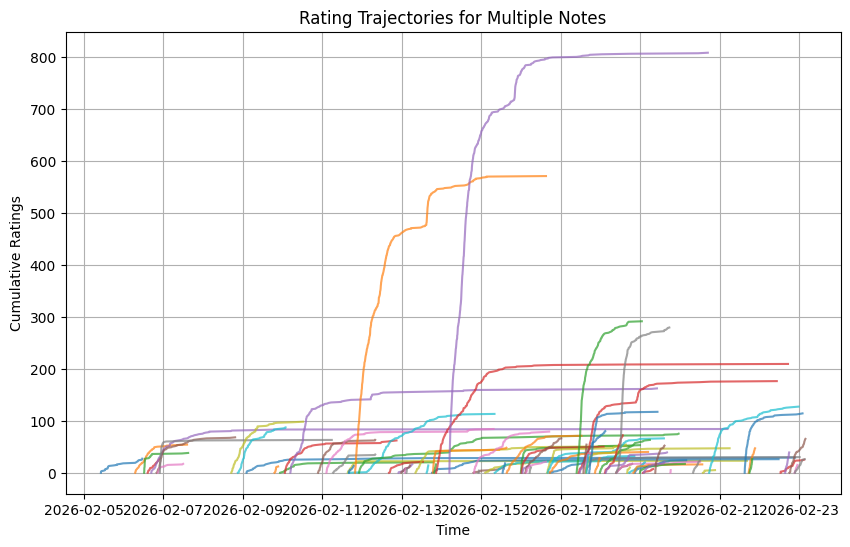

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rated_notes = collab_with_status[
    collab_with_status['currentStatus'].isin([
        'CURRENTLY_RATED_HELPFUL',
        'CURRENTLY_RATED_NOT_HELPFUL'
    ])
]['noteId'].unique()

ratings_subset = ratings_all[
    ratings_all['noteId'].isin(rated_notes)
].copy()

sample_notes = ratings_subset['noteId'].drop_duplicates()

plt.figure(figsize=(10,6))

for note_id in sample_notes:

    df = ratings_subset[
        ratings_subset['noteId'] == note_id
    ].copy()

    df['time'] = pd.to_datetime(df['createdAtMillis'], unit='ms')
    df = df.sort_values('time')

    df['rating'] = 1
    df['cum_ratings'] = df['rating'].cumsum()

    plt.plot(
        df['time'],
        df['cum_ratings'],
        alpha=0.7
    )

plt.xlabel("Time")
plt.ylabel("Cumulative Ratings")
plt.title("Rating Trajectories for Multiple Notes")

plt.grid(True)
plt.show()

Number of rated notes: 88
Ratings rows: (5862, 5)


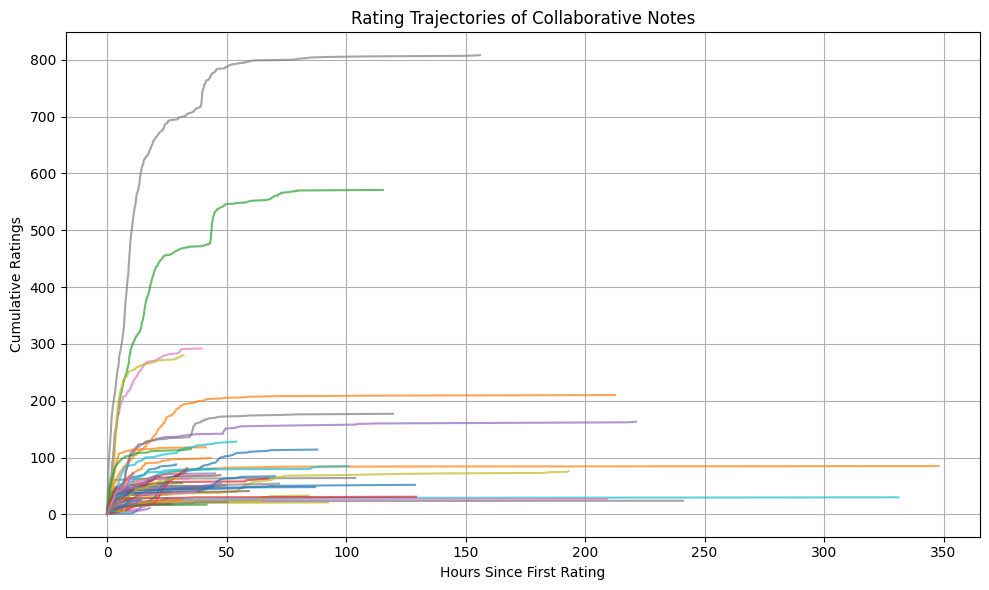

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rated_notes = collab_with_status[
    collab_with_status['currentStatus'].isin([
        'CURRENTLY_RATED_HELPFUL',
        'CURRENTLY_RATED_NOT_HELPFUL'
    ])
]['noteId'].unique()

print("Number of rated notes:", len(rated_notes))

ratings_subset = ratings_all[
    ratings_all['noteId'].isin(rated_notes)
].copy()

print("Ratings rows:", ratings_subset.shape)


ratings_subset['time'] = pd.to_datetime(
    ratings_subset['createdAtMillis'],
    unit='ms'
)

ratings_subset = ratings_subset.sort_values(['noteId', 'time'])


plt.figure(figsize=(10,6))

sample_notes = rated_notes

for note_id in sample_notes:

    df = ratings_subset[ratings_subset['noteId'] == note_id].copy()

    first_time = df['time'].min()
    df['hours_since_first'] = (
        df['time'] - first_time
    ).dt.total_seconds() / 3600

    df['rating'] = 1
    df['cum_ratings'] = df['rating'].cumsum()

    plt.plot(
        df['hours_since_first'],
        df['cum_ratings'],
        alpha=0.7
    )

plt.xlabel("Hours Since First Rating")
plt.ylabel("Cumulative Ratings")

plt.title("Rating Trajectories of Collaborative Notes")

plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
import re

def extract_urls(text):

    if pd.isna(text):
        return []

    return re.findall(r'https?://\S+', text)

collab["urls"] = collab["summary"].apply(extract_urls)

collab["num_urls"] = collab["urls"].apply(len)

In [ ]:
(collab["num_urls"] > 0).mean()

np.float64(1.0)

In [ ]:
collab["num_urls"].describe()

,num_urls
count,5312.000000
mean,2.377071
std,0.882872
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,9.000000


In [ ]:
collab[["summary","urls"]].head(10)

,summary,urls
2432704,"Claim that Avicii, Bennington, Cornell, Bourda...",[https://www.reuters.com/article/idUSKCN25F19S...
2432705,The video in this post is fabricated; no such ...,[https://www.france24.com/en/tv-shows/truth-or...
2432706,"The attack shown occurred in Bordeaux, France ...",[https://www.reuters.com/article/fact-check/bo...
2432707,Sources show ~7 German NGO ships were active i...,[https://www.thesocialpost.it/2023/09/30/quali...
2432708,Video shows 2021 flogging at Nigerian madrasa ...,[https://www.bbc.com/news/world-africa-5886996...
2432709,The post uses sarcasm to criticize immigration...,[https://x.com/RadioGenoa/status/1753381199160...
2432710,The post's video shows a real Feb 2024 inciden...,[https://x.com/metpoliceuk/status/175806831573...
2432711,Video shows Feb 2024 Uxbridge incident: police...,[https://www.reuters.com/fact-check/video-show...
2432712,The video is a 2019 clip of a man masturbating...,[https://xhamster.desi/videos/do-not-masturbat...
2432713,The video depicts a man apparently defecating ...,[https://www.nzz.ch/english/italian-platform-p...


In [ ]:
collab[collab["num_urls"] == 0].head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,isCollaborativeNote,urls,num_urls


In [ ]:
from urllib.parse import urlparse

def get_domain(url_list):
    if len(url_list) == 0:
        return None
    return urlparse(url_list[0]).netloc

collab["domain"] = collab["urls"].apply(get_domain)

collab["domain"].value_counts().head(20)

,count
domain,
x.com,595
en.wikipedia.org,371
www.bbc.com,134
www.youtube.com,124
science.nasa.gov,122
www.reuters.com,98
www.justice.gov,95
www.congress.gov,91
news.gallup.com,89


In [ ]:
import re

def extract_urls(text):

    if pd.isna(text):
        return []

    return re.findall(r'https?://\S+', text)

collab_with_status["urls"] = collab_with_status["summary"].apply(extract_urls)

In [ ]:
note_versions = ratings_all[['noteId','version']].drop_duplicates()

notes_versions = collab_with_status.merge(
    note_versions,
    on="noteId",
    how="left"
)

In [ ]:
note_version_urls = (
    notes_versions
    .groupby(["noteId","version"])["urls"]
    .first()
    .reset_index()
)

In [ ]:
note_version_urls["url_set"] = note_version_urls["urls"].apply(set)

In [ ]:
def compare_urls(old, new):

    added = new - old
    removed = old - new

    if len(added) > 0 and len(removed) > 0:
        return "swap"

    if len(added) > 0:
        return "add"

    if len(removed) > 0:
        return "remove"

    return "same"

In [ ]:
changes = []

for note_id, group in note_version_urls.groupby("noteId"):

    group = group.sort_values("version")

    urls = group["url_set"].tolist()

    for i in range(1, len(urls)):

        change = compare_urls(urls[i-1], urls[i])

        changes.append(change)

In [ ]:
change_series = pd.Series(changes)

print(change_series.value_counts(normalize=True))

Series([], Name: proportion, dtype: float64)


In [ ]:
note_version_urls["version"].value_counts()

,count
version,
2.0,4187
